In [1]:
!pip install torch numpy matplotlib

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Defining the PINN Model

class PINN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3,64),
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,3)
        )

    def forward(self,x):

        return self.net(x)


model = PINN().to(device)

In [5]:
# Generating the Flow Domain
# Generating random points

def generate_points(N):

    x = np.random.uniform(0,1.5,N)
    y = np.random.uniform(0,0.4,N)
    t = np.random.uniform(0,1,N)

    points = np.stack([x,y,t],axis=1)

    return torch.tensor(points,dtype=torch.float32)

In [6]:
# Removing points inside cylinder

def remove_cylinder(points):

    cx,cy = 0.3,0.2
    r = 0.05

    x = points[:,0]
    y = points[:,1]

    mask = ((x-cx)**2 + (y-cy)**2) > r**2

    return points[mask]

In [7]:
# Generating training data

N = 20000

points = generate_points(N)
points = remove_cylinder(points)

points = points.to(device)
points.requires_grad = True

In [8]:
# Automatic Differentiation

def gradients(u,x):

    return torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

In [9]:
# Navier-Stokes Residuals for incompressible flow

def navier_stokes_residual(model,X,nu):

    pred = model(X)

    u = pred[:,0:1]
    v = pred[:,1:2]
    p = pred[:,2:3]

    grads = gradients(pred,X)

    u_x = grads[:,0:1]
    u_y = grads[:,1:2]
    u_t = grads[:,2:3]

    v_x = grads[:,0:1]
    v_y = grads[:,1:2]
    v_t = grads[:,2:3]

    p_x = grads[:,0:1]
    p_y = grads[:,1:2]

    u_xx = gradients(u_x,X)[:,0:1]
    u_yy = gradients(u_y,X)[:,1:2]

    v_xx = gradients(v_x,X)[:,0:1]
    v_yy = gradients(v_y,X)[:,1:2]

    f_u = u_t + u*u_x + v*u_y + p_x - nu*(u_xx + u_yy)
    f_v = v_t + u*v_x + v*v_y + p_y - nu*(v_xx + v_yy)

    f_c = u_x + v_y

    return f_u,f_v,f_c

In [10]:
# Boundary Sampling Functions

def inlet_boundary(N):

    x = np.zeros(N)
    y = np.random.uniform(0,0.4,N)
    t = np.random.uniform(0,1,N)

    pts = np.stack([x,y,t],axis=1)

    return torch.tensor(pts,dtype=torch.float32)




def outlet_boundary(N):

    x = np.ones(N)*1.5
    y = np.random.uniform(0,0.4,N)
    t = np.random.uniform(0,1,N)

    pts = np.stack([x,y,t],axis=1)

    return torch.tensor(pts,dtype=torch.float32)




def top_boundary(N):

    x = np.random.uniform(0,1.5,N)
    y = np.ones(N)*0.4
    t = np.random.uniform(0,1,N)

    pts = np.stack([x,y,t],axis=1)

    return torch.tensor(pts,dtype=torch.float32)




def bottom_boundary(N):

    x = np.random.uniform(0,1.5,N)
    y = np.zeros(N)
    t = np.random.uniform(0,1,N)

    pts = np.stack([x,y,t],axis=1)

    return torch.tensor(pts,dtype=torch.float32)




def cylinder_boundary(N):

    cx,cy = 0.3,0.2
    r = 0.05

    theta = np.random.uniform(0,2*np.pi,N)

    x = cx + r*np.cos(theta)
    y = cy + r*np.sin(theta)
    t = np.random.uniform(0,1,N)

    pts = np.stack([x,y,t],axis=1)

    return torch.tensor(pts,dtype=torch.float32)


In [11]:
# Generating Boundary Data

N_boundary = 2000

inlet = inlet_boundary(N_boundary).to(device)
outlet = outlet_boundary(N_boundary).to(device)

top = top_boundary(N_boundary).to(device)
bottom = bottom_boundary(N_boundary).to(device)

cylinder = cylinder_boundary(N_boundary).to(device)

In [12]:
# Boundary Loss

def boundary_loss(model):

    loss = 0

    pred = model(inlet)
    u = pred[:,0]
    v = pred[:,1]
    loss += ((u-1)**2).mean() + (v**2).mean()

    pred = model(outlet)
    p = pred[:,2]
    loss += (p**2).mean()

    pred = model(top)
    u = pred[:,0]
    v = pred[:,1]
    loss += (u**2).mean() + (v**2).mean()

    pred = model(bottom)
    u = pred[:,0]
    v = pred[:,1]
    loss += (u**2).mean() + (v**2).mean()

    pred = model(cylinder)
    u = pred[:,0]
    v = pred[:,1]
    loss += (u**2).mean() + (v**2).mean()

    return loss

In [13]:
# Training

optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

nu = 0.01
epochs = 5000

for epoch in range(epochs):

    optimizer.zero_grad()

    f_u,f_v,f_c = navier_stokes_residual(model,points,nu)

    physics_loss = (f_u**2).mean() + (f_v**2).mean() + (f_c**2).mean()

    bc_loss = boundary_loss(model)

    loss = physics_loss + bc_loss

    loss.backward()

    optimizer.step()

    if epoch % 200 == 0:

        print(epoch,loss.item())

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


0 1.1091686487197876
200 0.05547856539487839
400 0.02319524437189102
600 0.015416408888995647
800 0.016780508682131767
1000 0.013124402612447739
1200 0.014278929680585861
1400 0.009013095870614052
1600 0.009789412841200829
1800 0.012319158762693405
2000 0.0068913111463189125
2200 0.006123020313680172
2400 0.006248923484236002
2600 0.005799305159598589
2800 0.005802287720143795
3000 0.015619584359228611
3200 0.005419373046606779
3400 0.005562175996601582
3600 0.007098315749317408
3800 0.0051855044439435005
4000 0.004789196886122227
4200 0.004662453196942806
4400 0.005895051173865795
4600 0.007726432755589485
4800 0.004436631686985493


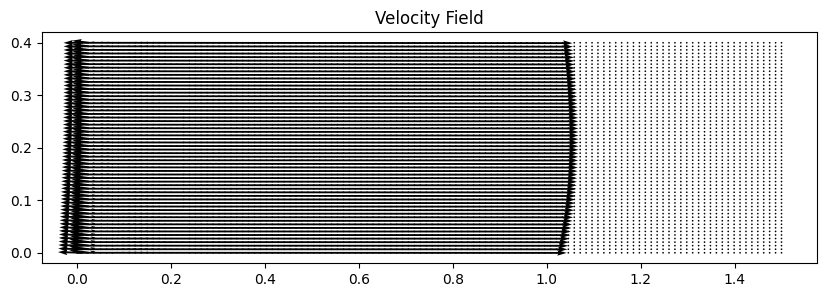

In [15]:
# Velocity Field Visualization

x = np.linspace(0,1.5,120)
y = np.linspace(0,0.4,60)

X,Y = np.meshgrid(x,y)

t = np.zeros_like(X)

grid = np.stack([X.flatten(),Y.flatten(),t.flatten()],axis=1)

grid = torch.tensor(grid, dtype=torch.float32).to(device)

with torch.no_grad():

    pred = model(grid)

u = pred[:,0].cpu().numpy()
v = pred[:,1].cpu().numpy()

plt.figure(figsize=(10,3))

plt.quiver(X,Y,u.reshape(X.shape),v.reshape(X.shape))

plt.title("Velocity Field")

plt.show()

In [16]:
# Vorticity Visualization

grid.requires_grad = True

pred = model(grid)

u = pred[:,0:1]
v = pred[:,1:2]

grads = gradients(pred,grid)

u_y = grads[:,1:2]
v_x = grads[:,0:1]

omega = v_x - u_y

omega = omega.detach().cpu().numpy()

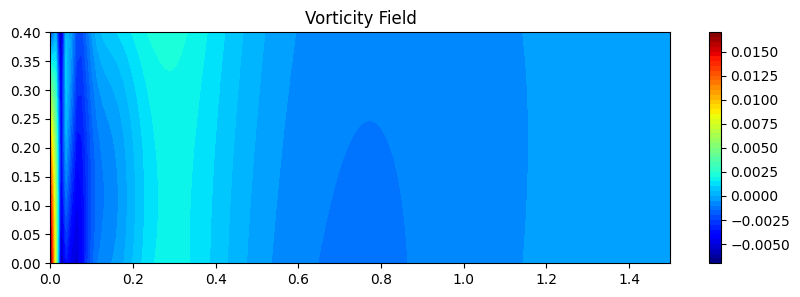

In [17]:
# Plotting

plt.figure(figsize=(10,3))

plt.contourf(
    X,
    Y,
    omega.reshape(X.shape),
    levels=50,
    cmap="jet"
)

plt.colorbar()

plt.title("Vorticity Field")

plt.show()

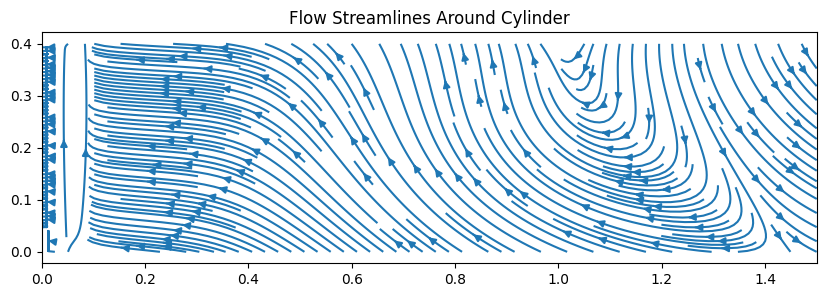

In [20]:
# Streamline Visualization



# reshape velocity
u_np = u.reshape(X.shape)
v_np = v.reshape(X.shape)

# convert to numpy safely
if torch.is_tensor(u_np):
    u_np = u_np.detach().cpu().numpy()

if torch.is_tensor(v_np):
    v_np = v_np.detach().cpu().numpy()

plt.figure(figsize=(10,3))

plt.streamplot(
    X,
    Y,
    u_np,
    v_np,
    density=2
)

plt.title("Flow Streamlines Around Cylinder")

plt.show()

In [21]:
# Reynolds Number Experiments

nu = 0.01

In [22]:
Re_values = [20,50,100]

U = 1
L = 0.1

for Re in Re_values:

    nu = U*L/Re

    print("Training for Reynolds number:",Re)
    print("Viscosity:",nu)

    model = PINN().to(device)

    optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

    for epoch in range(4000):

        optimizer.zero_grad()

        f_u,f_v,f_c = navier_stokes_residual(model,points,nu)

        physics_loss = (f_u**2).mean() + (f_v**2).mean() + (f_c**2).mean()

        bc_loss = boundary_loss(model)

        loss = physics_loss + bc_loss

        loss.backward()

        optimizer.step()

    print("Training finished for Re =",Re)

Training for Reynolds number: 20
Viscosity: 0.005
Training finished for Re = 20
Training for Reynolds number: 50
Viscosity: 0.002
Training finished for Re = 50
Training for Reynolds number: 100
Viscosity: 0.001
Training finished for Re = 100


In [23]:
torch.save(model.state_dict(),f"pinn_Re_{Re}.pth")

Text(0.5, 1.0, 'Streamlines (Re = 100)')

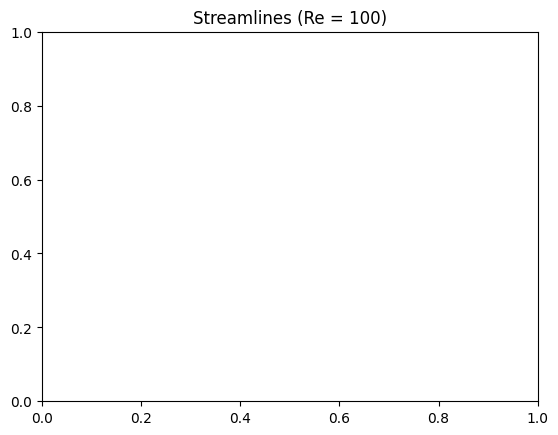

In [24]:
plt.title(f"Streamlines (Re = {Re})")